In [1]:
# Step 1: Install and Import Libraries
!pip install wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import re
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords', quiet=True)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


###ABOUT THE DATASETS
Training data has the answers exposed so the AI can learn. Validation data hides the answers to test if the AI actually learned anything, or if it just memorized the training data.


In [2]:
# Step 2: Load the Datasets
import pandas as pd

# Load training data
train_df = pd.read_csv('/content/twitter_training.csv', header=None)

# Load validation data (we'll use it later)
val_df = pd.read_csv('/content/twitter_validation.csv', header=None)



In [3]:
# Naming the columns
train_df.columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']
val_df.columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']

print("CHECKING THE HEADERS")
print("Training datae rows and columns:", train_df.shape)
print("\n First 5 rows:")
print(train_df.head())

print("\nSentiment Category count in Training Data:")
print(train_df['Sentiment'].value_counts())

CHECKING THE HEADERS
Training datae rows and columns: (74682, 4)

 First 5 rows:
   Tweet_ID       Entity Sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Sentiment Category count in Training Data:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [4]:
# Step 3: Data Cleaning

# Keeping the necessary  columns only
train_df = train_df[['Tweet', 'Sentiment']].copy()

# Drop rows where Tweet is missing
train_df = train_df.dropna(subset=['Tweet'])

# Replace 'Irrelevant' with 'Neutral' (makes it cleaner)
train_df['Sentiment'] = train_df['Sentiment'].replace('Irrelevant', 'Neutral')

print("✅ Data Cleaning Done!")
print("Shape after cleaning:", train_df.shape)
print("\nSentiment Distribution:")
print(train_df['Sentiment'].value_counts())

# We use stop_words='english' to automatically drop words like 'the', 'is', 'and'

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)        # Remove special characters & numbers
    text = ' '.join(word for word in text.split()
                    if word not in stopwords.words('english'))  # Remove stopwords
    return text

# Apply cleaning on training data.

train_df['Cleaned_Tweet'] = train_df['Tweet'].apply(clean_text)

print("\n✅ Text Cleaning Completed!")
print("\nSample before & after cleaning:")
print("Original:", train_df['Tweet'].iloc[0])
print("Cleaned :", train_df['Cleaned_Tweet'].iloc[0])

✅ Data Cleaning Done!
Shape after cleaning: (73996, 2)

Sentiment Distribution:
Sentiment
Neutral     30983
Negative    22358
Positive    20655
Name: count, dtype: int64

✅ Text Cleaning Completed!

Sample before & after cleaning:
Original: im getting on borderlands and i will murder you all ,
Cleaned : im getting borderlands murder


Feature Engineering + Train-Test Split

In [5]:
# Step 4: Convert Text to Numbers (TF-IDF) + Split Data

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Convert cleaned text into numerical features
vectorizer = TfidfVectorizer(max_features=5000)  # Using top 5000 words
X = vectorizer.fit_transform(train_df['Cleaned_Tweet'])
y = train_df['Sentiment']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Feature Engineering Done!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

✅ Feature Engineering Done!
Training samples: 59196
Testing samples: 14800
Number of features: 5000


In [6]:
# Step 5: Train the Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("✅ Model Training Completed!")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Model Training Completed!
Accuracy: 0.7274 (72.74%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.73      0.74      4380
     Neutral       0.72      0.77      0.74      6301
    Positive       0.72      0.66      0.69      4119

    accuracy                           0.73     14800
   macro avg       0.73      0.72      0.72     14800
weighted avg       0.73      0.73      0.73     14800



###Visualizations

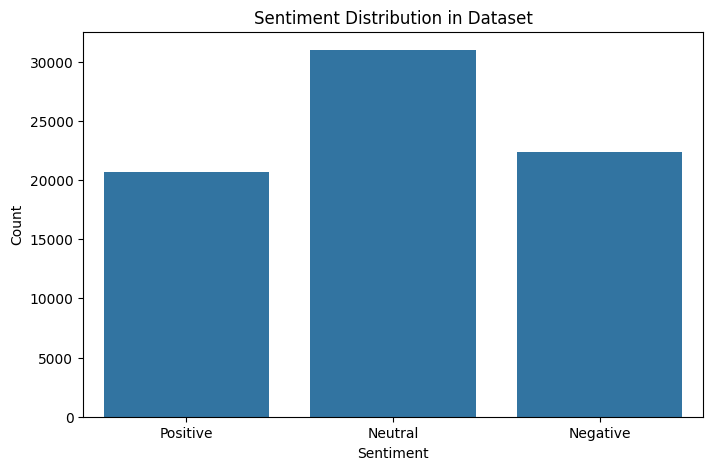

✅ Visualizations Completed!


In [7]:
# Step 6: Visualizations

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


plt.figure(figsize=(8,5))
sns.countplot(x=train_df['Sentiment'])
plt.title('Sentiment Distribution in Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

print("✅ Visualizations Completed!")

In [8]:


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join(word for word in text.split()
                    if word not in stopwords.words('english'))
    return text

def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector).max()

    print("Tweet:", text)
    print("Predicted Sentiment:", prediction)
    print(f"Confidence: {probability:.2f}")
    print("-" * 50)

print("🔥 Testing the Model:\n")
predict_sentiment("I absolutely love this product! It's fantastic.")
predict_sentiment("This is the worst service I have ever experienced.")
predict_sentiment("The movie was okay, nothing special.")
predict_sentiment("I am so excited for the new update!")

🔥 Testing the Model:

Tweet: I absolutely love this product! It's fantastic.
Predicted Sentiment: Positive
Confidence: 0.71
--------------------------------------------------
Tweet: This is the worst service I have ever experienced.
Predicted Sentiment: Negative
Confidence: 0.88
--------------------------------------------------
Tweet: The movie was okay, nothing special.
Predicted Sentiment: Neutral
Confidence: 0.62
--------------------------------------------------
Tweet: I am so excited for the new update!
Predicted Sentiment: Positive
Confidence: 0.89
--------------------------------------------------
